In [2]:
!pip install --upgrade pip
!pip install transformers tensorflow datasets scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


**Charger et préparer GoEmotions**

In [3]:
from datasets import load_dataset

# Charger GoEmotions (train/test/validation)
dataset = load_dataset("go_emotions")

# Afficher un exemple
print(dataset["train"][0])
# Voir la structure
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [4]:
all_labels = dataset["train"].features["labels"].feature.names
print("Toutes les étiquettes :", all_labels)

# Choix d'exemple : 6 émotions principales
selected = ["joy", "sadness", "anger", "fear", "love", "surprise"]
selected_ids = [all_labels.index(l) for l in selected]
print("Selected ids:", selected_ids)

Toutes les étiquettes : ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Selected ids: [17, 25, 2, 14, 18, 26]


In [5]:
import pandas as pd

def simplify_dataset(split):
    rows = []
    for ex in dataset[split]:
        labels = ex["labels"]  # liste des IDs (multi-label)
        # trouver la première étiquette parmi nos 6 émotions sélectionnées
        chosen_label = None
        for i in selected_ids:
            if i in labels:
                chosen_label = i
                break
        if chosen_label is not None:
            rows.append({
                "text": ex["text"],
                "label": all_labels[chosen_label]  # nom de l'émotion
            })
    return pd.DataFrame(rows)

train_df = simplify_dataset("train")
val_df   = simplify_dataset("validation")
test_df  = simplify_dataset("test")

print("Train size:", len(train_df))
print(train_df.head())
print("Répartition des labels:\n", train_df['label'].value_counts())

Train size: 7894
                                                text     label
0                     WHY THE FUCK IS BAYLESS ISOING     anger
1                        To make her feel threatened      fear
2  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...  surprise
3                                    Fucking coward.     anger
4              Stupidly stubborn / stubbornly stupid     anger
Répartition des labels:
 label
love        1996
anger       1546
joy         1452
sadness     1313
surprise    1015
fear         572
Name: count, dtype: int64


**Préparer BERT pour TensorFlow**

In [6]:
from transformers import TFBertForSequenceClassification, BertTokenizer

model_name = "bert-base-uncased"

# Charger le tokenizer
tokenizer = BertTokenizer.from_pretrained(model_name)

# Charger le modèle BERT préentraîné et convertir depuis PyTorch
model = TFBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    from_pt=True
)

print("✅ Modèle chargé avec succès :", model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Modèle chargé avec succès : bert-base-uncased


**Convertir en tf.data.Dataset pour BERT**

In [7]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Encodage des labels texte en entiers
le = LabelEncoder()
train_df["label_id"] = le.fit_transform(train_df["label"])
val_df["label_id"] = le.transform(val_df["label"])
test_df["label_id"] = le.transform(test_df["label"])

def encode_examples(df):
    tokens = tokenizer(
        list(df["text"]),
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="tf"
    )
    dataset = tf.data.Dataset.from_tensor_slices((
        dict(tokens),
        tf.convert_to_tensor(df["label_id"])
    ))
    return dataset.shuffle(1000).batch(16)

train_data = encode_examples(train_df)
val_data = encode_examples(val_df)
test_data = encode_examples(test_df)

print("✅ Jeux de données TensorFlow créés")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


✅ Jeux de données TensorFlow créés


**Créer et compiler le modèle BERT**

In [10]:
# ✅ Compilation du modèle
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ["accuracy"]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# 🧠 Callback : arrêt anticipé si le modèle ne s'améliore plus
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',          # Surveille la perte de validation
    patience=2,                  # Arrête si pas d'amélioration après 2 époques
    restore_best_weights=True    # Restaure les meilleurs poids
)

# 🔥 Entraînement complet
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,                   # Jusqu’à 10 époques max
    callbacks=[callback]         # Early stopping
)

Epoch 1/10
494/494 [==============================] - 276s 438ms/step - loss: 0.7351 - accuracy: 0.7565 - val_loss: 0.4315 - val_accuracy: 0.8580
Epoch 2/10
494/494 [==============================] - 210s 424ms/step - loss: 0.2968 - accuracy: 0.9111 - val_loss: 0.4236 - val_accuracy: 0.8727
Epoch 3/10
494/494 [==============================] - 209s 423ms/step - loss: 0.1817 - accuracy: 0.9464 - val_loss: 0.4388 - val_accuracy: 0.8716
Epoch 4/10
494/494 [==============================] - 209s 423ms/step - loss: 0.1011 - accuracy: 0.9726 - val_loss: 0.4663 - val_accuracy: 0.8674


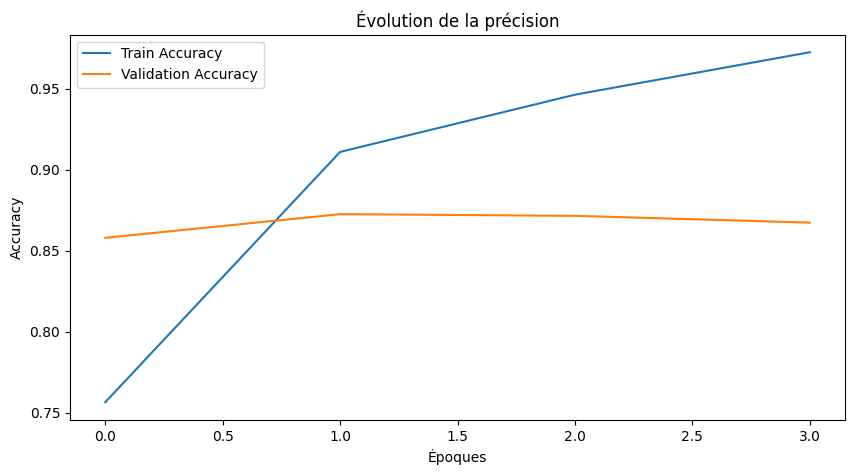

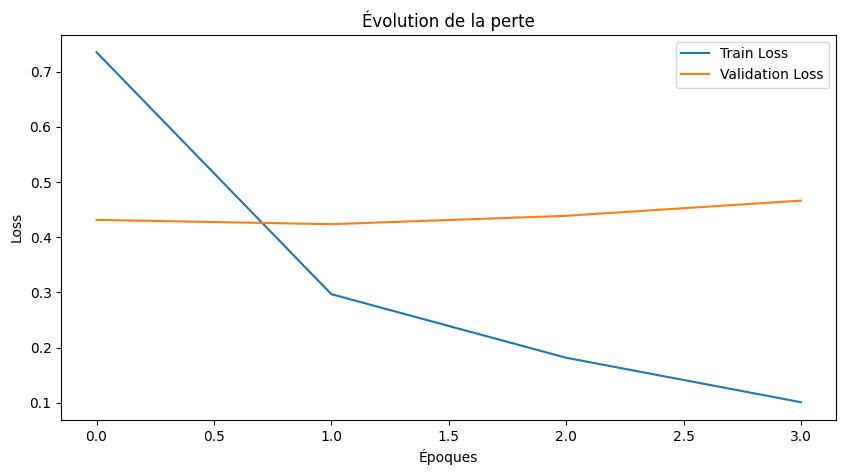

In [11]:
import matplotlib.pyplot as plt

# 📊 Courbe de précision
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de la précision')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 📉 Courbe de la perte
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la perte')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [12]:
# ⚡️ Évaluation sur le test set
test_loss, test_acc = model.evaluate(test_data)
print(f"✅ Test accuracy : {test_acc:.4f}")
print(f"🧾 Test loss : {test_loss:.4f}")


60/60 [==============================] - 9s 148ms/step - loss: 0.4575 - accuracy: 0.8577
✅ Test accuracy : 0.8577
🧾 Test loss : 0.4575


In [13]:
from transformers import BertTokenizer
import tensorflow as tf

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# ✏️ Exemple de texte à prédire
texts = [
    "I love how beautiful this place is!",      # émotion positive
    "I'm really sad about what happened.",      # émotion négative
    "This movie was just okay, nothing special." # neutre
]

# Tokenisation
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="tf"
)

# Prédiction
predictions = model(inputs)
predicted_labels = tf.argmax(predictions.logits, axis=1)

# Affichage
for text, label in zip(texts, predicted_labels):
    print(f"Texte : {text}")
    print(f"→ Prédiction : {label.numpy()}")
    print("--------------------------------------------------")


Texte : I love how beautiful this place is!
→ Prédiction : 3
--------------------------------------------------
Texte : I'm really sad about what happened.
→ Prédiction : 4
--------------------------------------------------
Texte : This movie was just okay, nothing special.
→ Prédiction : 2
--------------------------------------------------


In [15]:
import tensorflow as tf
import numpy as np

# Stocker les vraies labels et prédictions
y_true = []
y_pred = []

for batch in test_data:
    inputs, labels = batch
    logits = model(inputs).logits
    predictions = tf.argmax(logits, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.numpy())
# Mapping des indices vers les noms d'émotions
id2label = {i: label for i, label in enumerate(le.classes_)}

# Afficher 10 exemples aléatoires du test set
import random

indices = random.sample(range(len(test_df)), 10)

for i in indices:
    text = test_df.iloc[i]['text']
    true_label = id2label[y_true[i]]
    pred_label = id2label[y_pred[i]]
    print(f"Texte : {text}")
    print(f"→ Label vrai : {true_label}")
    print(f"→ Prédiction : {pred_label}")
    print("--------------------------------------------------")


Texte : Left handers are rejoicing over this
→ Label vrai : anger
→ Prédiction : anger
--------------------------------------------------
Texte : I want someone to take me to the hospital
→ Label vrai : anger
→ Prédiction : anger
--------------------------------------------------
Texte : When [NAME] pisses off his daughter and wife. Daughter: “You’re not my Daddy anymore” [NAME]: “You’re not my Daddy anymore either”
→ Label vrai : sadness
→ Prédiction : sadness
--------------------------------------------------
Texte : He’s going to the Bengals at 11 and I hate it so much
→ Label vrai : fear
→ Prédiction : fear
--------------------------------------------------
Texte : Offense does too. Love [NAME] but he's hurting our spacing being out there so much.
→ Label vrai : fear
→ Prédiction : fear
--------------------------------------------------
Texte : Yikes. This kind of freaks me out.
→ Label vrai : surprise
→ Prédiction : surprise
--------------------------------------------------
Texte

In [16]:
for i in random.sample(range(len(test_df)), 5):
    text = test_df.iloc[i]['text']
    true_label = id2label[y_true[i]]

    # Encoder le texte
    inputs = tokenizer(text, return_tensors="tf", truncation=True, padding='max_length', max_length=128)

    # Prédiction
    logits = model(inputs).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]

    print(f"Texte : {text}")
    print(f"→ Label vrai : {true_label}")
    print("→ Probabilités :")
    for j, p in enumerate(probs):
        print(f"   {id2label[j]} : {p:.2f}")
    print(f"→ Prédiction : {id2label[np.argmax(probs)]}")
    print("--------------------------------------------------")


Texte : i love this subreddit
→ Label vrai : joy
→ Probabilités :
   anger : 0.00
   fear : 0.00
   joy : 0.01
   love : 0.99
   sadness : 0.00
   surprise : 0.00
→ Prédiction : love
--------------------------------------------------
Texte : Omg what the ever loving bloody hell did I just read?? As an artist, this was extra painful to me.
→ Label vrai : joy
→ Probabilités :
   anger : 0.04
   fear : 0.02
   joy : 0.00
   love : 0.00
   sadness : 0.93
   surprise : 0.01
→ Prédiction : sadness
--------------------------------------------------
Texte : I'm literally screaming.
→ Label vrai : sadness
→ Probabilités :
   anger : 0.11
   fear : 0.72
   joy : 0.01
   love : 0.01
   sadness : 0.13
   surprise : 0.03
→ Prédiction : fear
--------------------------------------------------
Texte : I’d be verrrrrrrry nervous if we hired him. Would love him as an OC tho
→ Label vrai : joy
→ Probabilités :
   anger : 0.00
   fear : 0.01
   joy : 0.01
   love : 0.97
   sadness : 0.00
   surprise : 0.0